<a href="https://colab.research.google.com/github/gimangwai-tech/VISI_KOMPUTER/blob/main/filter_bentuk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving mobil.jpg to mobil (6).jpg


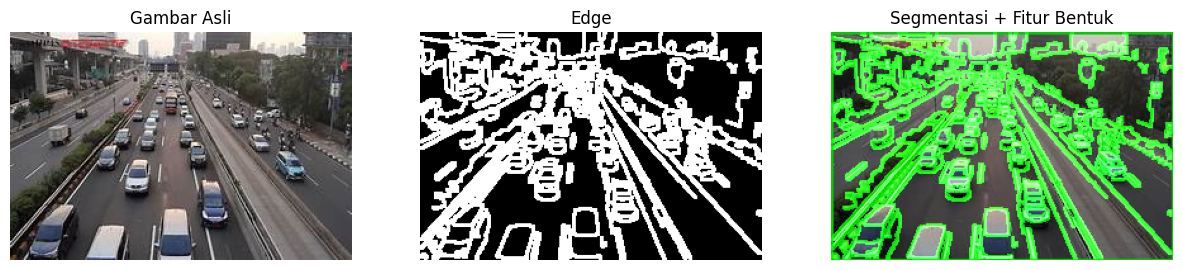

In [22]:
# ============================================
# IMPORT LIBRARY
# ============================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================
# UPLOAD GAMBAR
# ============================================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ============================================
# LOAD GAMBAR
# ============================================
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ============================================
# PREPROCESSING
# ============================================
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# ============================================
# EDGE DETECTION
# ============================================
edges = cv2.Canny(blur, 50, 150)

# Perjelas edge
kernel = np.ones((3,3), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

# ============================================
# CONTOUR DETECTION
# ============================================
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copy gambar untuk output
output = image_rgb.copy()

# ============================================
# EKSTRAKSI FITUR BENTUK + DETEKSI MOBIL
# ============================================
for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 2000:  # filter noise
        perimeter = cv2.arcLength(cnt, True)

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)

        # circularity
        if perimeter != 0:
            circularity = 4 * np.pi * area / (perimeter**2)
        else:
            circularity = 0

        # filter bentuk mobil
        if 1.2 < aspect_ratio < 4.5:
            # kotak mobil
            cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0), 2)

            # teks fitur
            text = f"A:{int(area)} AR:{aspect_ratio:.2f}"
            cv2.putText(output, text, (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (255,0,0), 2)

# ============================================
# SEGMENTASI EDGE WARNA HIJAU
# ============================================
green_edges = np.zeros_like(image_rgb)
green_edges[:,:,1] = edges

# Gabungkan edge + hasil deteksi
combined = cv2.addWeighted(output, 0.8, green_edges, 0.8, 0)

# ============================================
# TAMPILKAN HASIL
# ============================================
plt.figure(figsize=(15,5))

# 1. Gambar Asli
plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Gambar Asli")
plt.axis('off')

# 2. Edge
plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge")
plt.axis('off')

# 3. Segmentasi + Fitur
plt.subplot(1,3,3)
plt.imshow(combined)
plt.title("Segmentasi + Fitur Bentuk")
plt.axis('off')

plt.show()